In [1]:
import os

print(os.listdir("/kaggle/input/datasets/yalumusic/magnatagatune"))

['MagnaTagATune', 'annotations_final.csv']


In [2]:
print(os.listdir("/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music"))

['DEAM_audio', 'features', 'DEAM_Annotations']


# **load the annotation file**

In [3]:
import pandas as pd

mtat_root = "/kaggle/input/datasets/yalumusic/magnatagatune"
annotations_path = f"{mtat_root}/annotations_final.csv"

tags_df = pd.read_csv(annotations_path, sep="\t")

print(tags_df.shape)
tags_df.head()

(25863, 190)


,clip_id,no voice,singer,duet,plucking,hard rock,world,bongos,harpsichord,female singing,...,rap,metal,hip hop,quick,water,baroque,women,fiddle,english,mp3_path
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...
1,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...
2,10,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...
3,11,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...
4,12,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...


# **Find the top 50  tags**

In [4]:
tag_columns = tags_df.columns[1:-1]  # drops clip_id (first) and mp3_path (last)
tag_counts = tags_df[tag_columns].sum().sort_values(ascending=False)

top_50_tags = tag_counts.head(50).index.tolist()
print(top_50_tags)

['guitar', 'classical', 'slow', 'techno', 'strings', 'drums', 'electronic', 'rock', 'fast', 'piano', 'ambient', 'beat', 'violin', 'vocal', 'synth', 'female', 'indian', 'opera', 'male', 'singing', 'vocals', 'no vocals', 'harpsichord', 'loud', 'quiet', 'flute', 'woman', 'male vocal', 'no vocal', 'pop', 'soft', 'sitar', 'solo', 'man', 'classic', 'choir', 'voice', 'new age', 'dance', 'female vocal', 'male voice', 'beats', 'harp', 'cello', 'no voice', 'weird', 'country', 'metal', 'female voice', 'choral']


# **Keep only clips that have at least one of those 50 tags**

In [5]:
mtat_df = tags_df[tags_df[top_50_tags].sum(axis=1) > 0].reset_index(drop=True)

print("Clips before filtering:", len(tags_df))
print("Clips after filtering:", len(mtat_df))

Clips before filtering: 25863
Clips after filtering: 21111


# **Peek at the actual audio folder structure**

In [6]:
print(os.listdir(f"{mtat_root}/MagnaTagATune"))

['7', '2', 'b', 'f', '5', 'e', '8', '0', 'a', '3', '1', 'c', '4', '9', '6', 'd']


In [7]:
deam_root = "/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music"
print(os.listdir(f"{deam_root}/DEAM_audio"))
print(os.listdir(f"{deam_root}/DEAM_Annotations"))

['MEMD_audio']
['annotations']


# **check what mp3_path actually looks like**

In [8]:
print(mtat_df["mp3_path"].iloc[0])

f/american_bach_soloists-j_s__bach_solo_cantatas-01-bwv54__i_aria-30-59.mp3


# **Build the full path to that one clip and load it**

In [9]:
import librosa

audio_dir = f"{mtat_root}/MagnaTagATune"
first_clip_path = f"{audio_dir}/{mtat_df['mp3_path'].iloc[0]}"

print("Full path:", first_clip_path)
print("File exists:", os.path.exists(first_clip_path))

y, sr = librosa.load(first_clip_path, sr=22050, mono=True)
print("Waveform shape:", y.shape)
print("Sample rate:", sr)
print("Duration (seconds):", len(y) / sr)

Full path: /kaggle/input/datasets/yalumusic/magnatagatune/MagnaTagATune/f/american_bach_soloists-j_s__bach_solo_cantatas-01-bwv54__i_aria-30-59.mp3
File exists: True
Waveform shape: (642185,)
Sample rate: 22050
Duration (seconds): 29.124036281179137


# **Turn that waveform into something a model can actually see, and look at it**

Mel-spectrogram shape: (128, 1255)


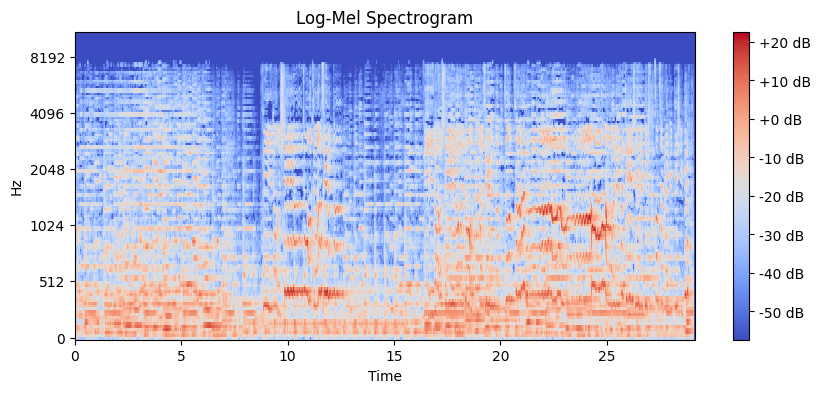

In [10]:
import matplotlib.pyplot as plt

mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
log_mel = librosa.power_to_db(mel, ref=1.0)

print("Mel-spectrogram shape:", log_mel.shape)  # (128 frequency bins, some number of time frames)

plt.figure(figsize=(10, 4))
librosa.display.specshow(log_mel, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title("Log-Mel Spectrogram")
plt.show()

# **Imports, device, folders**

In [11]:
import os
import pandas as pd
import numpy as np
import librosa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

for folder in ["data/splits", "data/processed", "results/checkpoints", "results/plots"]:
    os.makedirs(folder, exist_ok=True)

Device: cuda


# **Load MTAT annotations, top-50 tags, mtat_df**

In [12]:
mtat_root = "/kaggle/input/datasets/yalumusic/magnatagatune"
audio_dir = f"{mtat_root}/MagnaTagATune"

tags_df = pd.read_csv(f"{mtat_root}/annotations_final.csv", sep="\t")
tag_columns = tags_df.columns[1:-1]
tag_counts = tags_df[tag_columns].sum().sort_values(ascending=False)
top_50_tags = tag_counts.head(50).index.tolist()

mtat_df = tags_df[tags_df[top_50_tags].sum(axis=1) > 0].reset_index(drop=True)
mtat_df["folder"] = mtat_df["mp3_path"].str.split("/").str[0]

print("Clips after filtering:", len(mtat_df))

Clips after filtering: 21111


# **Train/val/test split by folder**

In [13]:
train_folders = list("0123456789ab")
val_folders = ["c"]
test_folders = ["d", "e", "f"]

train_df = mtat_df[mtat_df["folder"].isin(train_folders)].reset_index(drop=True)
val_df = mtat_df[mtat_df["folder"].isin(val_folders)].reset_index(drop=True)
test_df = mtat_df[mtat_df["folder"].isin(test_folders)].reset_index(drop=True)

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))

Train: 15250 | Val: 1529 | Test: 4332


# **Save splits to disk**

In [14]:
train_df.to_csv("data/splits/train.csv", index=False)
val_df.to_csv("data/splits/val.csv", index=False)
test_df.to_csv("data/splits/test.csv", index=False)
print("Saved.")

Saved.


# **Feature extraction functions**

In [15]:
def load_audio(path, sr=22050):
    y, sr = librosa.load(path, sr=sr, mono=True)
    return y, sr

def get_melspectrogram(y, sr, n_mels=128):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    log_mel = librosa.power_to_db(mel, ref=1.0).T
    mean = log_mel.mean(axis=0, keepdims=True)
    std = log_mel.std(axis=0, keepdims=True) + 1e-8
    return (log_mel - mean) / std

def get_chroma(y, sr, n_chroma=12):
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=n_chroma).T
    mean = chroma.mean(axis=0, keepdims=True)
    std = chroma.std(axis=0, keepdims=True) + 1e-8
    return (chroma - mean) / std

def split_into_segments(feature_matrix, sr, hop_length=512, window_seconds=5.0):
    frames_per_segment = int(window_seconds * sr / hop_length)
    segments = []
    for start in range(0, feature_matrix.shape[0], frames_per_segment):
        chunk = feature_matrix[start:start + frames_per_segment]
        if len(chunk) > 0:
            segments.append(chunk.mean(axis=0))
    return segments

In [16]:
first_clip_path = f"{audio_dir}/{mtat_df['mp3_path'].iloc[0]}"

y, sr = load_audio(first_clip_path)
mel = get_melspectrogram(y, sr)
segments = split_into_segments(mel, sr)

print("Number of segments:", len(segments))

Number of segments: 6


# **Plot the spectrogram**

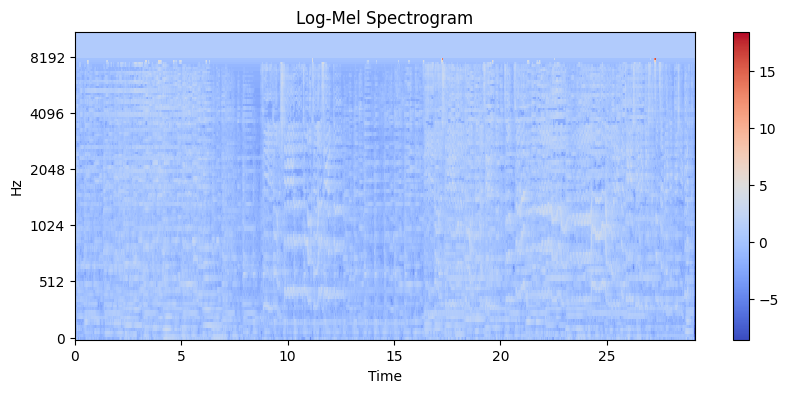

In [17]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10, 4))
librosa.display.specshow(mel.T, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar()
plt.title("Log-Mel Spectrogram")
plt.show()

# **Graph functions**

In [18]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

def build_segment_graph(segments, similarity_threshold=0.5):
    n = len(segments)
    edges = set()
    for i in range(n - 1):
        edges.add((i, i + 1))
    for i in range(n):
        for j in range(i + 1, n):
            if cosine_similarity(segments[i], segments[j]) > similarity_threshold:
                edges.add((i, j))
    return list(edges)

def process_clip(path):
    y, sr = load_audio(path)
    mel = get_melspectrogram(y, sr)
    segs = split_into_segments(mel, sr)
    edges = build_segment_graph(segs)
    return segs, edges

# **Visualize the one clip's graph**

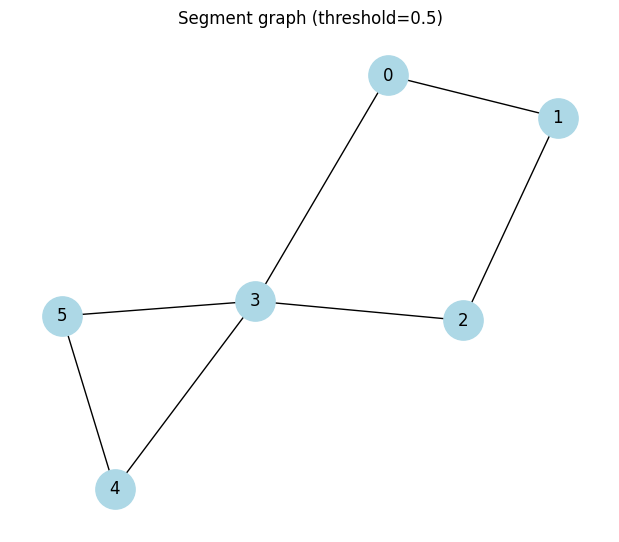

In [19]:
import networkx as nx

edges = build_segment_graph(segments, similarity_threshold=0.5)

G = nx.Graph()
G.add_nodes_from(range(len(segments)))
G.add_edges_from(edges)

plt.figure(figsize=(6, 5))
nx.draw(G, with_labels=True, node_color="lightblue", node_size=800)
plt.title("Segment graph (threshold=0.5)")
plt.show()

# **Classical vs. techno, one clip each**

In [20]:
classical_clips = mtat_df[mtat_df["classical"] == 1]
techno_clips = mtat_df[mtat_df["techno"] == 1]

classical_path = f"{audio_dir}/{classical_clips['mp3_path'].iloc[0]}"
techno_path = f"{audio_dir}/{techno_clips['mp3_path'].iloc[0]}"

classical_segs, classical_edges = process_clip(classical_path)
techno_segs, techno_edges = process_clip(techno_path)

print("Classical:", len(classical_segs), "segments,", len(classical_edges), "edges")
print("Techno:   ", len(techno_segs), "segments,", len(techno_edges), "edges")

Classical: 6 segments, 7 edges
Techno:    6 segments, 6 edges


# **Visualize side by side**

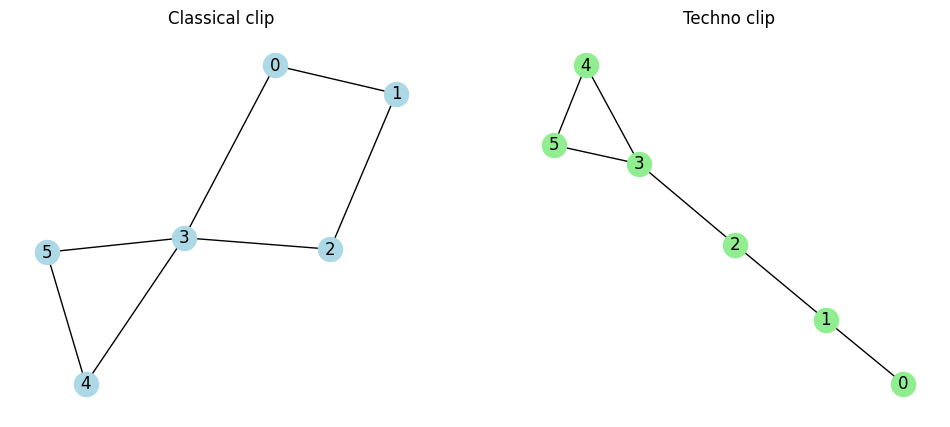

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

G1 = nx.Graph(); G1.add_nodes_from(range(len(classical_segs))); G1.add_edges_from(classical_edges)
nx.draw(G1, with_labels=True, node_color="lightblue", ax=axes[0])
axes[0].set_title("Classical clip")

G2 = nx.Graph(); G2.add_nodes_from(range(len(techno_segs))); G2.add_edges_from(techno_edges)
nx.draw(G2, with_labels=True, node_color="lightgreen", ax=axes[1])
axes[1].set_title("Techno clip")
plt.show()

# **The stronger, 20-clips-per-genre check**

In [22]:
def average_extra_edges(clips_df, n_samples=20):
    extra_counts = []
    for path in clips_df["mp3_path"].iloc[:n_samples]:
        segs, edges = process_clip(f"{audio_dir}/{path}")
        extra_counts.append(len(edges) - (len(segs) - 1))
    return sum(extra_counts) / len(extra_counts)

classical_avg = average_extra_edges(classical_clips)
techno_avg = average_extra_edges(techno_clips)
print("Classical avg extra edges:", classical_avg)
print("Techno avg extra edges:", techno_avg)

Classical avg extra edges: 1.55
Techno avg extra edges: 3.75


# **Task 1: BERT**

# **Load BERT + tokenizer**

In [23]:
!pip install -q transformers
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# **Pseudo-caption for one clip**

In [24]:
one_clip = mtat_df.iloc[0]
clip_tags = [tag for tag in top_50_tags if one_clip[tag] == 1]
pseudo_caption = " ".join(clip_tags) if clip_tags else "[no tags]"
print("Tags:", clip_tags)
print("Pseudo-caption:", pseudo_caption)

Tags: ['classical', 'strings', 'violin', 'opera']
Pseudo-caption: classical strings violin opera


# **Tokenize it**

In [25]:
tokens = tokenizer(pseudo_caption, return_tensors="pt")
print("Input IDs:", tokens["input_ids"])
print("Decoded:", tokenizer.decode(tokens["input_ids"][0]))

Input IDs: tensor([[ 101, 4556, 7817, 6710, 3850,  102]])
Decoded: [CLS] classical strings violin opera [SEP]


# **Model class**

In [26]:
class BertTagClassifier(nn.Module):
    def __init__(self, bert, num_tags=50):
        super().__init__()
        self.bert = bert
        self.classifier = nn.Linear(768, num_tags)

    def forward(self, input_ids, attention_mask):
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_vector = output.last_hidden_state[:, 0, :]
        return self.classifier(cls_vector)

# **Layer freezing function**

In [27]:
def freeze_bottom_layers(bert, num_layers_to_freeze=8):
    for param in bert.embeddings.parameters():
        param.requires_grad = False
    for layer in bert.encoder.layer[:num_layers_to_freeze]:
        for param in layer.parameters():
            param.requires_grad = False

# **Dataset class**

In [28]:
class TagDataset(Dataset):
    def __init__(self, df, tag_columns, tokenizer, max_length=32, mask_ratio=0.5, seed=42):
        self.df = df.reset_index(drop=True)
        self.tag_columns = tag_columns
        self.tokenizer = tokenizer
        self.max_length = max_length

        rng = np.random.RandomState(seed)
        self.captions = []
        for i in range(len(self.df)):
            row = self.df.iloc[i]
            true_tags = [tag for tag in tag_columns if row[tag] == 1]
            if not true_tags:
                self.captions.append("[no tags]")
                continue
            n_keep = max(1, round(len(true_tags) * (1 - mask_ratio)))
            kept = rng.choice(true_tags, size=n_keep, replace=False)
            self.captions.append(" ".join(kept))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        tokens = self.tokenizer(
            self.captions[idx], padding="max_length", truncation=True,
            max_length=self.max_length, return_tensors="pt",
        )
        label = row[self.tag_columns].values.astype("float32")
        return {
            "input_ids": tokens["input_ids"].squeeze(0),
            "attention_mask": tokens["attention_mask"].squeeze(0),
            "label": torch.tensor(label),
        }

# **Sanity check on 8 clips**

In [29]:
small_dataset = TagDataset(mtat_df.iloc[:8], top_50_tags, tokenizer)
loader = DataLoader(small_dataset, batch_size=4, shuffle=True)
batch = next(iter(loader))
print("input_ids:", batch["input_ids"].shape, "| label:", batch["label"].shape)

input_ids: torch.Size([4, 32]) | label: torch.Size([4, 50])


# **Evaluation function**

In [30]:
from sklearn.metrics import f1_score, average_precision_score

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        logits = model(input_ids, attention_mask)
        all_logits.append(logits.cpu())
        all_labels.append(batch["label"])

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    probs = torch.sigmoid(all_logits).numpy()
    preds = (probs > 0.5).astype(int)
    labels_np = all_labels.numpy()

    return {
        "macro_f1": f1_score(labels_np, preds, average="macro", zero_division=0),
        "micro_f1": f1_score(labels_np, preds, average="micro", zero_division=0),
        "pr_auc": average_precision_score(labels_np, probs, average="macro"),
    }

# **Training function (with real per-epoch history)**

In [31]:
def train_task1(train_df, val_df, test_df, top_50_tags, device, num_epochs=25, patience=5):
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    bert = AutoModel.from_pretrained("bert-base-uncased")
    freeze_bottom_layers(bert, num_layers_to_freeze=8)

    model = BertTagClassifier(bert, num_tags=len(top_50_tags)).to(device)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
    loss_fn = nn.BCEWithLogitsLoss()

    train_loader = DataLoader(TagDataset(train_df, top_50_tags, tokenizer), batch_size=32, shuffle=True)
    val_loader = DataLoader(TagDataset(val_df, top_50_tags, tokenizer), batch_size=32, shuffle=False)
    test_loader = DataLoader(TagDataset(test_df, top_50_tags, tokenizer), batch_size=32, shuffle=False)

    best_val_f1, best_state, best_epoch, epochs_without_improvement = 0.0, None, None, 0
    history = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids, attention_mask)
            loss = loss_fn(logits, labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()

        val_metrics = evaluate(model, val_loader, device)
        avg_train_loss = total_loss / len(train_loader)
        history.append({"epoch": epoch + 1, "train_loss": avg_train_loss, **{f"val_{k}": v for k, v in val_metrics.items()}})

        print(f"Epoch {epoch+1} | train loss: {avg_train_loss:.4f} | "
              f"val macro-F1: {val_metrics['macro_f1']:.4f} | val PR-AUC: {val_metrics['pr_auc']:.4f}")

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1, best_epoch = val_metrics["macro_f1"], epoch + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"No improvement for {patience} epochs — stopping early at epoch {epoch+1}.")
                break

    model.load_state_dict(best_state)
    test_metrics = evaluate(model, test_loader, device)
    print(f"Final test metrics (best epoch {best_epoch}):", test_metrics)
    return model, test_metrics, history, best_epoch

In [32]:
model, test_metrics, history, best_epoch = train_task1(train_df, val_df, test_df, top_50_tags, device, num_epochs=25)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | train loss: 0.2305 | val macro-F1: 0.3444 | val PR-AUC: 0.6453
Epoch 2 | train loss: 0.1329 | val macro-F1: 0.5632 | val PR-AUC: 0.7434
Epoch 3 | train loss: 0.1119 | val macro-F1: 0.6911 | val PR-AUC: 0.7692
Epoch 4 | train loss: 0.1024 | val macro-F1: 0.7043 | val PR-AUC: 0.7777
Epoch 5 | train loss: 0.0970 | val macro-F1: 0.7173 | val PR-AUC: 0.7808
Epoch 6 | train loss: 0.0934 | val macro-F1: 0.7156 | val PR-AUC: 0.7827
Epoch 7 | train loss: 0.0911 | val macro-F1: 0.7206 | val PR-AUC: 0.7830
Epoch 8 | train loss: 0.0892 | val macro-F1: 0.7167 | val PR-AUC: 0.7834
Epoch 9 | train loss: 0.0876 | val macro-F1: 0.7176 | val PR-AUC: 0.7829
Epoch 10 | train loss: 0.0863 | val macro-F1: 0.7224 | val PR-AUC: 0.7865
Epoch 11 | train loss: 0.0853 | val macro-F1: 0.7215 | val PR-AUC: 0.7876
Epoch 12 | train loss: 0.0844 | val macro-F1: 0.7218 | val PR-AUC: 0.7854
Epoch 13 | train loss: 0.0835 | val macro-F1: 0.7232 | val PR-AUC: 0.7853
Epoch 14 | train loss: 0.0826 | val macro-F1: 0

# **Save checkpoint + history**

In [36]:
import json
torch.save(model.state_dict(), "results/checkpoints/task1_bert.pt")
with open("results/task1_training_history.json", "w") as f:
    json.dump(history, f, indent=2)
with open("results/metrics.json", "w") as f:
    json.dump({"task1_bert": test_metrics}, f, indent=2, default=float)
print("Saved.")

Saved.


# **Plot the epoch curve**

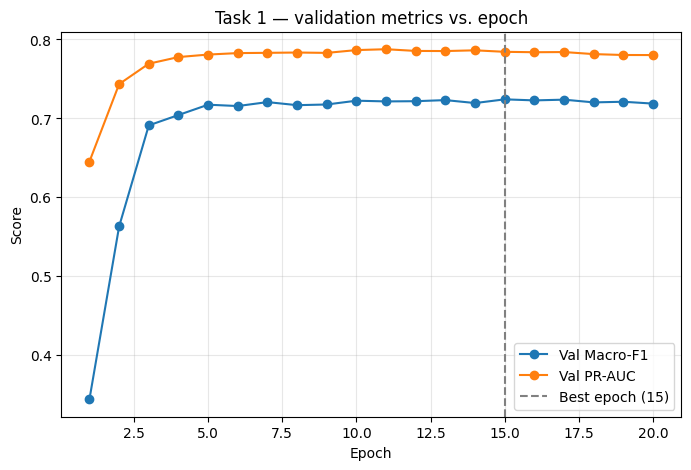

In [37]:
epochs_list = [h["epoch"] for h in history]
plt.figure(figsize=(8, 5))
plt.plot(epochs_list, [h["val_macro_f1"] for h in history], marker="o", label="Val Macro-F1")
plt.plot(epochs_list, [h["val_pr_auc"] for h in history], marker="o", label="Val PR-AUC")
plt.axvline(x=best_epoch, color="gray", linestyle="--", label=f"Best epoch ({best_epoch})")
plt.xlabel("Epoch"); plt.ylabel("Score"); plt.title("Task 1 — validation metrics vs. epoch")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("results/plots/task1_metrics_vs_epoch.png", dpi=150, bbox_inches="tight")
plt.show()

# **5 example predictions**

In [38]:
sample_df = test_df.sample(5, random_state=1).reset_index(drop=True)
sample_dataset = TagDataset(sample_df, top_50_tags, tokenizer, mask_ratio=0.5, seed=99)

for i in range(5):
    item = sample_dataset[i]
    input_ids = item["input_ids"].unsqueeze(0).to(device)
    attention_mask = item["attention_mask"].unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.sigmoid(model(input_ids, attention_mask)).cpu().numpy()[0]
    predicted = [top_50_tags[j] for j in range(50) if probs[j] > 0.5]
    true = [top_50_tags[j] for j in range(50) if item["label"][j] == 1]
    print(f"Example {i+1} | shown: {sample_dataset.captions[i]} | true: {true} | predicted: {predicted}\n")

Example 1 | shown: electronic techno | true: ['techno', 'drums', 'electronic', 'quiet'] | predicted: ['techno', 'electronic']

Example 2 | shown: voice vocals female vocal female voice | true: ['vocal', 'female', 'opera', 'vocals', 'woman', 'voice', 'female vocal', 'female voice'] | predicted: ['vocal', 'female', 'singing', 'vocals', 'woman', 'voice', 'female vocal', 'female voice']

Example 3 | shown: piano quiet | true: ['piano', 'quiet', 'harp'] | predicted: ['slow', 'piano', 'quiet']

Example 4 | shown: ambient | true: ['ambient'] | predicted: ['ambient']

Example 5 | shown: electronic fast | true: ['techno', 'drums', 'electronic', 'fast', 'beats'] | predicted: ['techno', 'electronic', 'fast']



In [40]:
import json

with open("results/metrics.json", "w") as f:
    json.dump({"task1_bert": test_metrics}, f, indent=2, default=float)
print("Saved final Task 1 metrics.")

Saved final Task 1 metrics.
